# Задание 10. Многопризнаковая контентная фильтрация для рекомендательных систем

## Задания
1. Загрузка и подготовка данных
2. Формирование текстового представления и кодирование
3. Сходство и рекомендации
4. Расширение набора признаков
5. Сравнительный анализ и выводы

## Импорты и конфигурация

In [1]:
import ast
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
WORKING_TOP_N = 8_000
SIMILARITY_DTYPE = np.float32
SELECTED_TITLES = ["Toy Story", "The Matrix", "Titanic"]

if "google.colab" in sys.modules:
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/module_10/data")
else:
    DATA_DIR = Path("data")

print("Каталог данных:", DATA_DIR)
print("Рабочий размер каталога для similarity-матрицы:", WORKING_TOP_N)
print("Предпочтительная модель эмбеддингов:", MODEL_NAME)

Каталог данных: data
Рабочий размер каталога для similarity-матрицы: 8000
Предпочтительная модель эмбеддингов: sentence-transformers/all-MiniLM-L6-v2


## Вспомогательные функции

In [2]:
def parse_name_list(value: Any) -> list[str]:
    if pd.isna(value):
        return []

    text = str(value).strip()
    if text in {"", "[]", "nan", "None"}:
        return []

    try:
        parsed = ast.literal_eval(text)
    except (ValueError, SyntaxError):
        return []

    if isinstance(parsed, dict):
        parsed = [parsed]

    result: list[str] = []
    for item in parsed:
        if isinstance(item, dict):
            name = str(item.get("name", "")).strip()
        else:
            name = str(item).strip()

        if name:
            result.append(" ".join(name.split()))

    return result


def list_to_text(items: list[str]) -> str:
    return ", ".join(items)


def estimate_similarity_matrix_gb(
    n_items: int, dtype: np.dtype = SIMILARITY_DTYPE
) -> float:
    bytes_total = n_items * n_items * np.dtype(dtype).itemsize
    return bytes_total / (1024**3)


def build_movie_label(row: pd.Series) -> str:
    year = row.get("release_year")
    if pd.notna(year):
        return f"{row['title']} ({int(year)})"
    return str(row["title"])


def prepare_keywords_table(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["keywords_length"] = result["keywords"].fillna("").astype(str).str.len()
    result = result.sort_values(["keywords_length"], ascending=False).drop_duplicates("id")
    return result.drop(columns=["keywords_length"])


def prepare_movies_table(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["vote_count"] = pd.to_numeric(result["vote_count"], errors="coerce").fillna(0)
    result["popularity"] = pd.to_numeric(result["popularity"], errors="coerce").fillna(0)
    result = result.sort_values(["vote_count", "popularity"], ascending=False).drop_duplicates("id")
    return result


def select_working_catalog(df: pd.DataFrame, top_n: int = WORKING_TOP_N) -> pd.DataFrame:
    working = df[df["title"].ne("") & df["content_text"].ne("")].copy()
    working = working.sort_values(["vote_count", "popularity"], ascending=False).head(top_n)
    working = working.reset_index(drop=True)
    working["movie_label"] = working.apply(build_movie_label, axis=1)
    return working


def build_embedding_backend(model_name: str = MODEL_NAME) -> tuple[str, Any]:
    try:
        from sentence_transformers import SentenceTransformer  # type: ignore
    except ImportError:
        return "local-fallback", None

    try:
        model = SentenceTransformer(model_name, device="cpu", local_files_only=True)
    except Exception:
        return "local-fallback", None

    return "sentence-transformer", model


def encode_texts(
    texts: pd.Series, model_name: str = MODEL_NAME
) -> tuple[np.ndarray, dict[str, str]]:
    text_list = texts.fillna("").astype(str).tolist()
    backend_name, backend_obj = build_embedding_backend(model_name)

    if backend_name == "sentence-transformer":
        embeddings = backend_obj.encode(
            text_list,
            batch_size=128,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        info = {
            "backend": "sentence-transformer",
            "label": model_name,
            "note": "Используется локально доступная MiniLM-модель без сетевых скачиваний.",
        }
        return np.asarray(embeddings, dtype=SIMILARITY_DTYPE), info

    vectorizer = TfidfVectorizer(
        max_features=20_000,
        min_df=2,
        ngram_range=(1, 2),
        stop_words="english",
    )
    tfidf_matrix = vectorizer.fit_transform(text_list)
    n_components = min(256, tfidf_matrix.shape[0] - 1, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    embeddings = svd.fit_transform(tfidf_matrix)
    embeddings = normalize(embeddings).astype(SIMILARITY_DTYPE)
    info = {
        "backend": "local-fallback",
        "label": "TF-IDF + TruncatedSVD (offline fallback)",
        "note": "Пакет sentence-transformers недоступен в текущем окружении, поэтому используется локальный dense fallback без интернет-загрузок.",
    }
    return embeddings, info


def compute_similarity_matrix(embeddings: np.ndarray) -> np.ndarray:
    return (embeddings @ embeddings.T).astype(SIMILARITY_DTYPE)


def resolve_title_index(catalog: pd.DataFrame, title: str) -> int:
    candidates = catalog[catalog["title"].eq(title)].copy()
    if candidates.empty:
        raise KeyError(f"Фильм '{title}' не найден в рабочем каталоге.")

    candidates = candidates.sort_values(["vote_count", "popularity"], ascending=False)
    return int(candidates.index[0])


def recommend_top_k(
    title: str,
    catalog: pd.DataFrame,
    similarity_matrix: np.ndarray,
    top_k: int = 10,
) -> pd.DataFrame:
    source_idx = resolve_title_index(catalog, title)
    scores = similarity_matrix[source_idx].copy()
    scores[source_idx] = -1

    top_idx = np.argpartition(scores, -top_k)[-top_k:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]

    result = catalog.loc[top_idx, ["id", "title", "movie_label", "release_date", "vote_count"]].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result["similarity"] = scores[top_idx]
    result = result.reset_index(drop=True)
    return result


def plot_recommendations(recommendations: pd.DataFrame, title: str, subtitle: str) -> None:
    plot_df = recommendations.iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["movie_label"], plot_df["similarity"], color="#4C78A8")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Фильм")
    plt.xlim(0, 1)
    plt.title(f"{title}: {subtitle}")
    plt.tight_layout()
    plt.show()


def overlap_at_k(left: pd.DataFrame, right: pd.DataFrame) -> float:
    left_ids = set(left["id"].tolist())
    right_ids = set(right["id"].tolist())
    return len(left_ids & right_ids) / max(len(left_ids), 1)


def mean_similarity_at_k(recommendations: pd.DataFrame) -> float:
    return float(recommendations["similarity"].mean())


def summarize_shift(title: str, base_recs: pd.DataFrame, extended_recs: pd.DataFrame) -> str:
    overlap = overlap_at_k(base_recs, extended_recs)
    base_titles = set(base_recs["title"])
    extended_titles = set(extended_recs["title"])
    added = list(extended_titles - base_titles)
    removed = list(base_titles - extended_titles)

    if overlap >= 0.7:
        overlap_comment = "ядро рекомендаций почти полностью сохранилось"
    elif overlap >= 0.4:
        overlap_comment = "часть ядра сохранилась, но обновление заметно"
    else:
        overlap_comment = "список рекомендаций перестроился довольно сильно"

    delta = mean_similarity_at_k(extended_recs) - mean_similarity_at_k(base_recs)
    if delta > 0.02:
        sim_comment = "средняя близость выросла, то есть новый признак сделал соседей компактнее"
    elif delta < -0.02:
        sim_comment = "средняя близость немного снизилась, зато рекомендации стали разнообразнее"
    else:
        sim_comment = "средняя близость изменилась слабо, но состав соседей всё равно уточнился"

    added_comment = ", ".join(added[:3]) if added else "новых фильмов в топ-10 почти нет"
    removed_comment = ", ".join(removed[:3]) if removed else "из базового списка почти ничего не ушло"

    return (
        f"{title}: {overlap_comment}; {sim_comment}. "
        f"В новом списке появились: {added_comment}. "
        f"Из базового списка ушли: {removed_comment}."
    )

# Задание 1. Загрузка и подготовка данных

1. Загрузить `movies_metadata.csv` и `keywords.csv`
2. Объединить таблицы по `id`
3. Удалить дубликаты и обработать пропуски
4. Распарсить JSON-поля в списки строк
5. Кратко описать итоговый DataFrame

## Загрузите оба CSV и проверьте исходные размеры

In [3]:
movies_raw = pd.read_csv(DATA_DIR / "movies_metadata.csv", low_memory=False)
keywords_raw = pd.read_csv(DATA_DIR / "keywords.csv")

movies_raw_columns = movies_raw.shape[1]
keywords_raw_columns = keywords_raw.shape[1]

movies_raw["id_num"] = pd.to_numeric(movies_raw["id"], errors="coerce")
keywords_raw["id_num"] = pd.to_numeric(keywords_raw["id"], errors="coerce")

raw_summary = pd.DataFrame(
    {
        "table": ["movies_metadata", "keywords"],
        "rows": [len(movies_raw), len(keywords_raw)],
        "columns": [movies_raw_columns, keywords_raw_columns],
        "invalid_id": [
            movies_raw["id_num"].isna().sum(),
            keywords_raw["id_num"].isna().sum(),
        ],
        "duplicate_id": [
            movies_raw["id_num"].dropna().duplicated().sum(),
            keywords_raw["id_num"].dropna().duplicated().sum(),
        ],
    }
)

display(raw_summary)
display(movies_raw[["id", "title", "genres", "release_date", "vote_count"]].head())
display(keywords_raw.head())

print("Комментарий:")
print("- В movies_metadata есть несколько строк с некорректным id, их нужно отбросить перед merge.")
print("- В обоих файлах встречаются дубликаты по id, поэтому объединять таблицы без предварительной очистки нельзя.")

,table,rows,columns,invalid_id,duplicate_id
0,movies_metadata,45466,24,3,30
1,keywords,46419,2,0,987


,id,title,genres,release_date,vote_count
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",1995-10-30,"5,415.000"
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",1995-12-15,"2,413.000"
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",1995-12-22,92.000
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",1995-12-22,34.000
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",1995-02-10,173.000


,id,keywords,id_num
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': 'toy'}, {'id': 5202, 'name': 'boy'}, {'id': 6054, 'name': 'fr...",862
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 10941, 'name': 'disappearance'}, {'id': 15101, 'name': ""based on childr...",8844
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392, 'name': 'best friend'}, {'id': 179431, 'name': 'duringcreditsstinger...",15602
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id': 10131, 'name': 'interracial relationship'}, {'id': 14768, 'name': 'si...",31357
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'name': 'midlife crisis'}, {'id': 2246, 'name': 'confidence'}, {'id': 49...",11862


Комментарий:
- В movies_metadata есть несколько строк с некорректным id, их нужно отбросить перед merge.
- В обоих файлах встречаются дубликаты по id, поэтому объединять таблицы без предварительной очистки нельзя.


## Объедините таблицы по id и удалите дубликаты

In [4]:
movies_clean = movies_raw.dropna(subset=["id_num"]).copy()
movies_clean["id"] = movies_clean["id_num"].astype("int64")
movies_clean = movies_clean.drop(columns=["id_num"])

keywords_clean = keywords_raw.dropna(subset=["id_num"]).copy()
keywords_clean["id"] = keywords_clean["id_num"].astype("int64")
keywords_clean = keywords_clean.drop(columns=["id_num"])

movies_prepared = prepare_movies_table(movies_clean)
keywords_prepared = prepare_keywords_table(keywords_clean)

catalog = movies_prepared.merge(keywords_prepared, on="id", how="left")

merge_summary = pd.DataFrame(
    {
        "metric": [
            "Строки после очистки movies",
            "Строки после очистки keywords",
            "Уникальных id после merge",
            "Дубликатов id после merge",
        ],
        "value": [
            len(movies_prepared),
            len(keywords_prepared),
            catalog["id"].nunique(),
            catalog["id"].duplicated().sum(),
        ],
    }
)

display(merge_summary)
display(catalog[["id", "title", "original_title", "release_date", "keywords"]].head())

print("Комментарий:")
print("- Для movies оставлен наиболее информативный экземпляр id: с максимальным vote_count и popularity.")
print("- Для keywords оставлена самая длинная строка keywords, чтобы не потерять теги при дублях.")
print("- После merge получили единый каталог фильмов без дублей по id.")

,metric,value
0,Строки после очистки movies,45433
1,Строки после очистки keywords,45432
2,Уникальных id после merge,45433
3,Дубликатов id после merge,0


,id,title,original_title,release_date,keywords
0,27205,Inception,Inception,2010-07-14,"[{'id': 1014, 'name': 'loss of lover'}, {'id': 1566, 'name': 'dream'}, {'id': 1930, 'name': 'kidnapping'}, {'id': 21..."
1,155,The Dark Knight,The Dark Knight,2008-07-16,"[{'id': 849, 'name': 'dc comics'}, {'id': 853, 'name': 'crime fighter'}, {'id': 1308, 'name': 'secret identity'}, {'..."
2,19995,Avatar,Avatar,2009-12-10,"[{'id': 1463, 'name': 'culture clash'}, {'id': 2964, 'name': 'future'}, {'id': 3386, 'name': 'space war'}, {'id': 33..."
3,24428,The Avengers,The Avengers,2012-04-25,"[{'id': 242, 'name': 'new york'}, {'id': 5539, 'name': 'shield'}, {'id': 8828, 'name': 'marvel comic'}, {'id': 9715,..."
4,293660,Deadpool,Deadpool,2016-02-09,"[{'id': 2095, 'name': 'anti hero'}, {'id': 3070, 'name': 'mercenary'}, {'id': 8828, 'name': 'marvel comic'}, {'id': ..."


Комментарий:
- Для movies оставлен наиболее информативный экземпляр id: с максимальным vote_count и popularity.
- Для keywords оставлена самая длинная строка keywords, чтобы не потерять теги при дублях.
- После merge получили единый каталог фильмов без дублей по id.


## Обработайте пропуски в genres и keywords, распарсите JSON-поля

In [5]:
missing_before = {
    "genres": catalog["genres"].isna().sum(),
    "keywords": catalog["keywords"].isna().sum(),
    "overview": catalog["overview"].isna().sum(),
    "title": catalog["title"].isna().sum(),
}

catalog["title"] = catalog["title"].fillna(catalog["original_title"]).fillna("").astype(str).str.strip()
catalog["overview"] = (
    catalog["overview"].fillna("").astype(str).str.replace("\n", " ", regex=False).str.strip()
)
catalog["release_date"] = catalog["release_date"].fillna("").astype(str)
catalog["release_dt"] = pd.to_datetime(catalog["release_date"], errors="coerce")
catalog["release_year"] = catalog["release_dt"].dt.year.astype("Int64")

for column in ["vote_count", "vote_average", "popularity", "runtime"]:
    catalog[column] = pd.to_numeric(catalog[column], errors="coerce")

catalog["genres"] = catalog["genres"].fillna("[]")
catalog["keywords"] = catalog["keywords"].fillna("[]")
catalog["genres_list"] = catalog["genres"].apply(parse_name_list)
catalog["keywords_list"] = catalog["keywords"].apply(parse_name_list)

parsed_sample = catalog[["title", "genres_list", "keywords_list", "overview"]].head(10).copy()
parsed_sample["overview"] = parsed_sample["overview"].apply(
    lambda text: (text[:120] + "...") if len(text) > 120 else text
)

missing_summary = pd.DataFrame(
    {
        "column": ["genres", "keywords", "overview", "title"],
        "missing_before": [
            missing_before["genres"],
            missing_before["keywords"],
            missing_before["overview"],
            missing_before["title"],
        ],
        "empty_after": [
            (catalog["genres_list"].apply(len) == 0).sum(),
            (catalog["keywords_list"].apply(len) == 0).sum(),
            catalog["overview"].eq("").sum(),
            catalog["title"].eq("").sum(),
        ],
    }
)

display(missing_summary)
display(parsed_sample)

print("Комментарий:")
print("- JSON-строки в genres и keywords успешно преобразованы в списки строк.")
print("- Пустые значения не удалялись целиком: они сохранены как пустые списки, чтобы не терять фильмы при merge.")

,column,missing_before,empty_after
0,genres,0,2442
1,keywords,1,14341
2,overview,954,959
3,title,3,0


,title,genres_list,keywords_list,overview
0,Inception,"[Action, Thriller, Science Fiction, Mystery, Adventure]","[loss of lover, dream, kidnapping, sleep, subconsciousness, heist, redemption, female hero]","Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a c..."
1,The Dark Knight,"[Drama, Action, Crime, Thriller]","[dc comics, crime fighter, secret identity, scarecrow, sadism, chaos, gotham city, vigilante, joker, superhero, base...","Batman raises the stakes in his war on crime. With the help of Lt. Jim Gordon and District Attorney Harvey Dent, Bat..."
2,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, space, alien, tribe, al...","In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn bet..."
3,The Avengers,"[Science Fiction, Action, Adventure]","[new york, shield, marvel comic, superhero, based on comic, alien invasion, superhero team, aftercreditsstinger, dur...","When an unexpected enemy emerges and threatens global safety and security, Nick Fury, director of the international ..."
4,Deadpool,"[Action, Adventure, Comedy]","[anti hero, mercenary, marvel comic, superhero, based on comic, breaking the fourth wall, aftercreditsstinger, durin...","Deadpool tells the origin story of former Special Forces operative turned mercenary Wade Wilson, who after being sub..."
5,Interstellar,"[Adventure, Drama, Science Fiction]","[saving the world, artificial intelligence, father son relationship, single parent, nasa, expedition, wormhole, spac...",Interstellar chronicles the adventures of a group of explorers who make use of a newly discovered wormhole to surpas...
6,Django Unchained,"[Drama, Western]","[bounty hunter, hero, plantation, society, friendship, friends, revenge, rivalry, rescue, shootout, racism, danger, ...","With the help of a German bounty hunter, a freed slave sets out to rescue his wife from a brutal Mississippi plantat..."
7,Guardians of the Galaxy,"[Action, Science Fiction, Adventure]","[marvel comic, spaceship, space, outer space, orphan, adventurer, aftercreditsstinger, duringcreditsstinger, marvel ...","Light years from Earth, 26 years after being abducted, Peter Quill finds himself the prime target of a manhunt after..."
8,Fight Club,[Drama],"[support group, dual identity, nihilism, rage and hate, insomnia, dystopia, violence]",A ticking-time-bomb insomniac and a slippery soap salesman channel primal male aggression into a shocking new form o...
9,The Hunger Games,"[Science Fiction, Adventure, Fantasy]","[hallucination, dystopia, female protagonist, bow and arrow, knife throwing, knife fight, game, archery, blindness, ...","Every year in the ruins of what was once North America, the nation of Panem forces each of its twelve districts to s..."


Комментарий:
- JSON-строки в genres и keywords успешно преобразованы в списки строк.
- Пустые значения не удалялись целиком: они сохранены как пустые списки, чтобы не терять фильмы при merge.


## Кратко опишите итоговый DataFrame

In [6]:
catalog["movie_label"] = catalog.apply(build_movie_label, axis=1)
catalog["content_text"] = (
    catalog["genres_list"].apply(list_to_text) + " | " + catalog["keywords_list"].apply(list_to_text)
).str.strip(" |")

summary_table = pd.DataFrame(
    {
        "metric": [
            "Число строк",
            "Уникальных id",
            "Непустых title",
            "Непустых overview",
            "Непустых content_text",
            "Среднее число жанров",
            "Среднее число keywords",
        ],
        "value": [
            len(catalog),
            catalog["id"].nunique(),
            catalog["title"].ne("").sum(),
            catalog["overview"].ne("").sum(),
            catalog["content_text"].ne("").sum(),
            round(catalog["genres_list"].apply(len).mean(), 2),
            round(catalog["keywords_list"].apply(len).mean(), 2),
        ],
    }
)

top_genres = (
    catalog.explode("genres_list")
    .loc[lambda frame: frame["genres_list"].notna() & frame["genres_list"].ne("")]
    ["genres_list"]
    .value_counts()
    .head(10)
    .rename_axis("genre")
    .reset_index(name="count")
)

display(summary_table)
display(catalog[["id", "movie_label", "genres_list", "keywords_list"]].head(10))
display(top_genres)

print("Комментарий:")
print("- После парсинга каждая запись содержит человекочитаемые списки жанров и ключевых слов.")
print("- Для рекомендательной системы уже достаточно базового текстового описания: жанры + тематические keywords.")

,metric,value
0,Число строк,"45,433.000"
1,Уникальных id,"45,433.000"
2,Непустых title,"45,433.000"
3,Непустых overview,"44,474.000"
4,Непустых content_text,"43,355.000"
5,Среднее число жанров,2.000
6,Среднее число keywords,3.450


,id,movie_label,genres_list,keywords_list
0,27205,Inception (2010),"[Action, Thriller, Science Fiction, Mystery, Adventure]","[loss of lover, dream, kidnapping, sleep, subconsciousness, heist, redemption, female hero]"
1,155,The Dark Knight (2008),"[Drama, Action, Crime, Thriller]","[dc comics, crime fighter, secret identity, scarecrow, sadism, chaos, gotham city, vigilante, joker, superhero, base..."
2,19995,Avatar (2009),"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, space, alien, tribe, al..."
3,24428,The Avengers (2012),"[Science Fiction, Action, Adventure]","[new york, shield, marvel comic, superhero, based on comic, alien invasion, superhero team, aftercreditsstinger, dur..."
4,293660,Deadpool (2016),"[Action, Adventure, Comedy]","[anti hero, mercenary, marvel comic, superhero, based on comic, breaking the fourth wall, aftercreditsstinger, durin..."
5,157336,Interstellar (2014),"[Adventure, Drama, Science Fiction]","[saving the world, artificial intelligence, father son relationship, single parent, nasa, expedition, wormhole, spac..."
6,68718,Django Unchained (2012),"[Drama, Western]","[bounty hunter, hero, plantation, society, friendship, friends, revenge, rivalry, rescue, shootout, racism, danger, ..."
7,118340,Guardians of the Galaxy (2014),"[Action, Science Fiction, Adventure]","[marvel comic, spaceship, space, outer space, orphan, adventurer, aftercreditsstinger, duringcreditsstinger, marvel ..."
8,550,Fight Club (1999),[Drama],"[support group, dual identity, nihilism, rage and hate, insomnia, dystopia, violence]"
9,70160,The Hunger Games (2012),"[Science Fiction, Adventure, Fantasy]","[hallucination, dystopia, female protagonist, bow and arrow, knife throwing, knife fight, game, archery, blindness, ..."


,genre,count
0,Drama,20244
1,Comedy,13176
2,Thriller,7619
3,Romance,6730
4,Action,6592
5,Horror,4671
6,Crime,4304
7,Documentary,3930
8,Adventure,3490
9,Science Fiction,3044


Комментарий:
- После парсинга каждая запись содержит человекочитаемые списки жанров и ключевых слов.
- Для рекомендательной системы уже достаточно базового текстового описания: жанры + тематические keywords.


# Задание 2. Формирование текстового представления и кодирование

1. Объединить `genres + keywords` в одну строку
2. Получить dense-эмбеддинги
3. Показать размер матрицы и кратко сравнить подход с TF-IDF

## Сформируйте строку: genres + keywords

In [7]:
catalog["content_text"] = (
    catalog["genres_list"].apply(list_to_text) + " | " + catalog["keywords_list"].apply(list_to_text)
).str.strip(" |")

working_catalog = select_working_catalog(catalog, top_n=WORKING_TOP_N)

selected_movies = (
    working_catalog[working_catalog["title"].isin(SELECTED_TITLES)]
    .sort_values(["title", "vote_count"], ascending=[True, False])
    .groupby("title", as_index=False)
    .head(1)
)

text_summary = pd.DataFrame(
    {
        "metric": [
            "Фильмов в полном каталоге",
            "Фильмов с непустым content_text",
            "Оценка размера полной similarity-матрицы (float32, ГБ)",
            f"Фильмов в рабочем каталоге top-{WORKING_TOP_N:,}",
            "Оценка размера рабочей similarity-матрицы (float32, ГБ)",
        ],
        "value": [
            len(catalog),
            catalog["content_text"].ne("").sum(),
            round(estimate_similarity_matrix_gb(catalog["content_text"].ne("").sum()), 2),
            len(working_catalog),
            round(estimate_similarity_matrix_gb(len(working_catalog)), 2),
        ],
    }
)

text_preview = working_catalog[["movie_label", "content_text"]].head(5).copy()
text_preview["content_text"] = text_preview["content_text"].apply(
    lambda text: (text[:160] + "...") if len(text) > 160 else text
)

display(text_summary)
display(text_preview)
display(selected_movies[["movie_label", "vote_count"]])

print("Комментарий:")
print("- Полная dense similarity-матрица для всех фильмов слишком тяжёлая по памяти, поэтому материализуем её для top-N наиболее популярных фильмов.")
print("- Такой каталог лучше подходит и practically: редкие фильмы с пустыми тегами обычно дают шумные рекомендации.")

,metric,value
0,Фильмов в полном каталоге,"45,433.000"
1,Фильмов с непустым content_text,"43,355.000"
2,"Оценка размера полной similarity-матрицы (float32, ГБ)",7.000
3,"Фильмов в рабочем каталоге top-8,000","8,000.000"
4,"Оценка размера рабочей similarity-матрицы (float32, ГБ)",0.240


,movie_label,content_text
0,Inception (2010),"Action, Thriller, Science Fiction, Mystery, Adventure | loss of lover, dream, kidnapping, sleep, subconsciousness, h..."
1,The Dark Knight (2008),"Drama, Action, Crime, Thriller | dc comics, crime fighter, secret identity, scarecrow, sadism, chaos, gotham city, v..."
2,Avatar (2009),"Action, Adventure, Fantasy, Science Fiction | culture clash, future, space war, space colony, society, space travel,..."
3,The Avengers (2012),"Science Fiction, Action, Adventure | new york, shield, marvel comic, superhero, based on comic, alien invasion, supe..."
4,Deadpool (2016),"Action, Adventure, Comedy | anti hero, mercenary, marvel comic, superhero, based on comic, breaking the fourth wall,..."


,movie_label,vote_count
12,The Matrix (1999),"9,079.000"
23,Titanic (1997),"7,770.000"
87,Toy Story (1995),"5,415.000"


Комментарий:
- Полная dense similarity-матрица для всех фильмов слишком тяжёлая по памяти, поэтому материализуем её для top-N наиболее популярных фильмов.
- Такой каталог лучше подходит и practically: редкие фильмы с пустыми тегами обычно дают шумные рекомендации.


## Получите эмбеддинги и покажите размер матрицы

In [8]:
base_embeddings, base_embedding_info = encode_texts(working_catalog["content_text"])

print("Используемый backend:", base_embedding_info["label"])
print(base_embedding_info["note"])
print("Форма матрицы эмбеддингов:", base_embeddings.shape)

embedding_preview = pd.DataFrame(base_embeddings[:5, :8], index=working_catalog["movie_label"].head(5))
embedding_preview.columns = [f"dim_{idx}" for idx in range(1, embedding_preview.shape[1] + 1)]
display(embedding_preview)

print("Комментарий:")
print("- Каждая строка превратилась в dense-вектор фиксированной длины.")
print("- Эти векторы уже можно сравнивать косинусной мерой без ручного конструирования разреженных признаков.")

Используемый backend: TF-IDF + TruncatedSVD (offline fallback)
Пакет sentence-transformers недоступен в текущем окружении, поэтому используется локальный dense fallback без интернет-загрузок.
Форма матрицы эмбеддингов: (8000, 256)


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
movie_label,,,,,,,,
Inception (2010),0.084,0.301,-0.293,0.010,-0.130,-0.052,-0.079,0.024
The Dark Knight (2008),0.069,0.242,-0.081,0.129,0.138,-0.017,-0.166,0.088
Avatar (2009),0.078,0.217,-0.224,-0.165,-0.148,-0.143,-0.100,0.004
The Avengers (2012),0.060,0.172,-0.235,-0.112,-0.079,-0.087,-0.125,0.016
Deadpool (2016),0.149,0.106,-0.174,-0.079,0.068,-0.053,-0.129,0.043


Комментарий:
- Каждая строка превратилась в dense-вектор фиксированной длины.
- Эти векторы уже можно сравнивать косинусной мерой без ручного конструирования разреженных признаков.


## Чем dense-эмбеддинги отличаются от TF-IDF

In [9]:
print(
    '''
Dense-эмбеддинги кодируют текст в компактный вектор фиксированной длины и стараются сохранить семантическую близость:
фильмы с похожими темами могут оказаться рядом даже при разном наборе слов.
TF-IDF, наоборот, строит высокоразмерное разреженное представление по конкретным токенам и сильнее зависит от буквальных совпадений.
Поэтому dense-подход удобнее для контентных рекомендаций, где важен смысл, а не только пересечение тегов.
    '''.strip()
)

Dense-эмбеддинги кодируют текст в компактный вектор фиксированной длины и стараются сохранить семантическую близость:
фильмы с похожими темами могут оказаться рядом даже при разном наборе слов.
TF-IDF, наоборот, строит высокоразмерное разреженное представление по конкретным токенам и сильнее зависит от буквальных совпадений.
Поэтому dense-подход удобнее для контентных рекомендаций, где важен смысл, а не только пересечение тегов.


# Задание 3. Сходство и рекомендации

1. Вычислить матрицу косинусного сходства
2. Выбрать 3 фильма
3. Для каждого фильма получить top-10 рекомендаций и кратко их прокомментировать

## Вычислите матрицу косинусного сходства

In [10]:
base_similarity = compute_similarity_matrix(base_embeddings)

similarity_preview = pd.DataFrame(
    base_similarity[:5, :5],
    index=working_catalog["movie_label"].head(5),
    columns=working_catalog["movie_label"].head(5),
)

print("Форма similarity-матрицы:", base_similarity.shape)
print("Тип данных:", base_similarity.dtype)
display(similarity_preview)

print("Комментарий:")
print("- На диагонали находятся единицы: фильм максимально похож сам на себя.")
print("- Вне диагонали видно, что даже по базовым тегам уже формируются устойчивые кластеры похожих фильмов.")

Форма similarity-матрицы: (8000, 8000)
Тип данных: float32


movie_label,Inception (2010),The Dark Knight (2008),Avatar (2009),The Avengers (2012),Deadpool (2016)
movie_label,,,,,
Inception (2010),1.000,0.068,0.122,0.100,0.102
The Dark Knight (2008),0.068,1.000,0.033,0.243,0.307
Avatar (2009),0.122,0.033,1.000,0.128,0.084
The Avengers (2012),0.100,0.243,0.128,1.000,0.781
Deadpool (2016),0.102,0.307,0.084,0.781,1.000


Комментарий:
- На диагонали находятся единицы: фильм максимально похож сам на себя.
- Вне диагонали видно, что даже по базовым тегам уже формируются устойчивые кластеры похожих фильмов.


## Получите топ-10 рекомендаций для выбранных фильмов

Рекомендации для 'Toy Story'


,rank,movie_label,vote_count,similarity
0,1,Small Soldiers (1998),522.000,0.773
1,2,Toy Story 3 (2010),"4,710.000",0.766
2,3,Pinocchio (1940),"1,412.000",0.756
3,4,The Transformers: The Movie (1986),134.000,0.752
4,5,Child's Play 2 (1990),323.000,0.747
5,6,Toy Story 2 (1999),"3,914.000",0.743
6,7,Bride of Chucky (1998),366.000,0.738
7,8,Ted (2012),"4,811.000",0.724
8,9,Annabelle (2014),"1,588.000",0.723
9,10,Curse of Chucky (2013),417.000,0.714


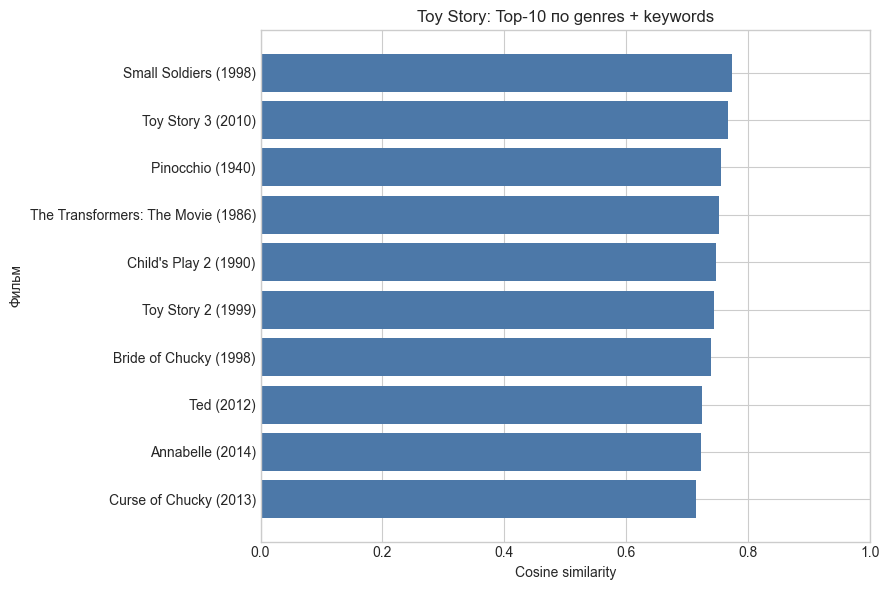

Рекомендации для 'The Matrix'


,rank,movie_label,vote_count,similarity
0,1,The Matrix Reloaded (2003),"3,500.000",0.823
1,2,The Matrix Revolutions (2003),"3,155.000",0.767
2,3,Terminator 3: Rise of the Machines (2003),"2,177.000",0.722
3,4,Ghost in the Shell (1995),854.000,0.641
4,5,Vice (2015),245.000,0.640
5,6,The Terminator (1984),"4,208.000",0.592
6,7,Virtuosity (1995),163.000,0.572
7,8,"I, Robot (2004)","3,889.000",0.564
8,9,The Thirteenth Floor (1999),381.000,0.561
9,10,Terminator Genisys (2015),"3,677.000",0.529


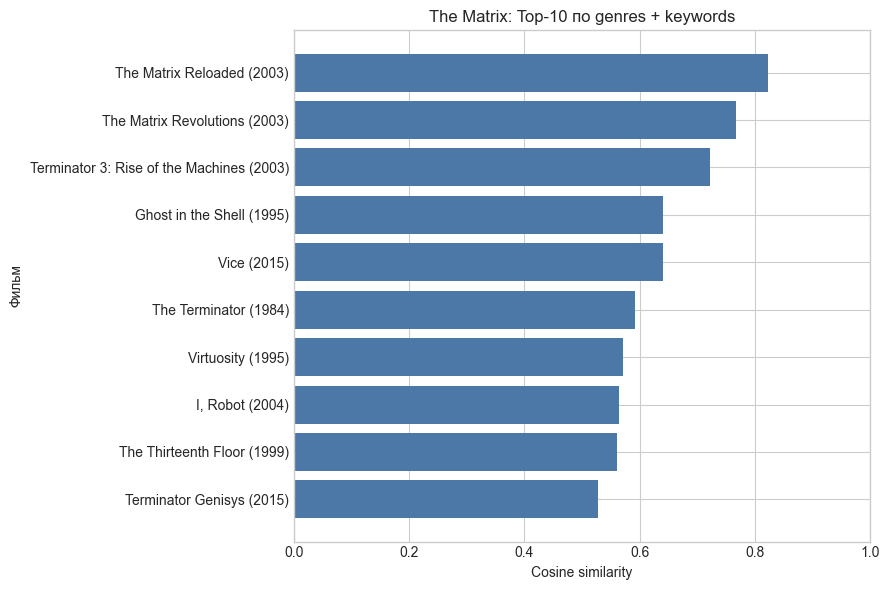

Рекомендации для 'Titanic'


,rank,movie_label,vote_count,similarity
0,1,Love Story (1970),123.000,0.580
1,2,A Moment to Remember (2004),75.000,0.497
2,3,Veer-Zaara (2004),67.000,0.496
3,4,Jab Tak Hai Jaan (2012),68.000,0.488
4,5,Broken Embraces (2009),167.000,0.487
5,6,A Short Film About Love (1988),65.000,0.485
6,7,Waiting for Forever (2010),122.000,0.476
7,8,Romeo + Juliet (1996),"1,406.000",0.469
8,9,Cruel Intentions (1999),848.000,0.439
9,10,The Deep Blue Sea (2011),82.000,0.437


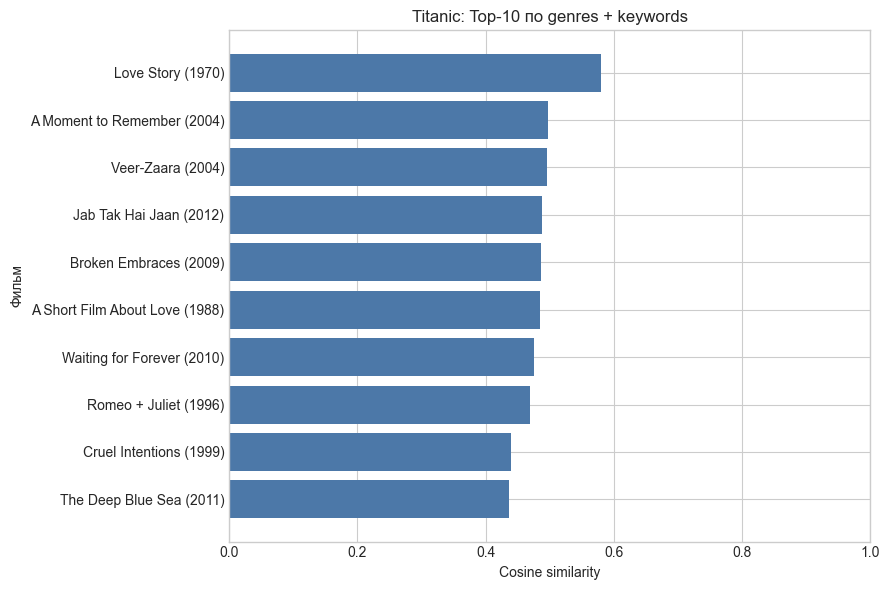

In [11]:
base_recommendations: dict[str, pd.DataFrame] = {}

for title in SELECTED_TITLES:
    recs = recommend_top_k(title, working_catalog, base_similarity, top_k=10)
    base_recommendations[title] = recs
    print(f"Рекомендации для '{title}'")
    display(recs[["rank", "movie_label", "vote_count", "similarity"]])
    plot_recommendations(recs, title, "Top-10 по genres + keywords")

## Краткий комментарий к базовым рекомендациям

In [12]:
for title in SELECTED_TITLES:
    recs = base_recommendations[title]
    top_titles = ", ".join(recs["title"].head(3).tolist())
    print(
        f"{title}: первые позиции занимают {top_titles}. "
        f"Средняя cosine similarity@10 = {mean_similarity_at_k(recs):.3f}."
    )

Toy Story: первые позиции занимают Small Soldiers, Toy Story 3, Pinocchio. Средняя cosine similarity@10 = 0.744.
The Matrix: первые позиции занимают The Matrix Reloaded, The Matrix Revolutions, Terminator 3: Rise of the Machines. Средняя cosine similarity@10 = 0.641.
Titanic: первые позиции занимают Love Story, A Moment to Remember, Veer-Zaara. Средняя cosine similarity@10 = 0.485.


# Задание 4. Расширение набора признаков

1. Добавить один новый признак до кодирования
2. Обосновать выбор
3. Пересчитать эмбеддинги, similarity и top-10 рекомендации

## Добавьте новый признак: overview и обоснуйте выбор

In [13]:
working_catalog_extended = working_catalog.copy()
working_catalog_extended["extended_text"] = (
    working_catalog_extended["content_text"] + " | " + working_catalog_extended["overview"]
).str.strip(" |")

extended_preview = working_catalog_extended[
    ["movie_label", "content_text", "overview", "extended_text"]
].head(5).copy()
for column in ["content_text", "overview", "extended_text"]:
    extended_preview[column] = extended_preview[column].apply(
        lambda text: (text[:140] + "...") if len(text) > 140 else text
    )

display(extended_preview)

print("Почему выбран overview:")
print("- Жанры и keywords хорошо описывают тему фильма, но плохо различают детали сюжета.")
print("- Overview добавляет событийный и семантический контекст: место действия, конфликт, героев и тип истории.")
print("- Для рекомендаций это полезно: система начинает искать не только по тегам, но и по смыслу описания.")

,movie_label,content_text,overview,extended_text
0,Inception (2010),"Action, Thriller, Science Fiction, Mystery, Adventure | loss of lover, dream, kidnapping, sleep, subconsciousness, h...","Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a c...","Action, Thriller, Science Fiction, Mystery, Adventure | loss of lover, dream, kidnapping, sleep, subconsciousness, h..."
1,The Dark Knight (2008),"Drama, Action, Crime, Thriller | dc comics, crime fighter, secret identity, scarecrow, sadism, chaos, gotham city, v...","Batman raises the stakes in his war on crime. With the help of Lt. Jim Gordon and District Attorney Harvey Dent, Bat...","Drama, Action, Crime, Thriller | dc comics, crime fighter, secret identity, scarecrow, sadism, chaos, gotham city, v..."
2,Avatar (2009),"Action, Adventure, Fantasy, Science Fiction | culture clash, future, space war, space colony, society, space travel,...","In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn bet...","Action, Adventure, Fantasy, Science Fiction | culture clash, future, space war, space colony, society, space travel,..."
3,The Avengers (2012),"Science Fiction, Action, Adventure | new york, shield, marvel comic, superhero, based on comic, alien invasion, supe...","When an unexpected enemy emerges and threatens global safety and security, Nick Fury, director of the international ...","Science Fiction, Action, Adventure | new york, shield, marvel comic, superhero, based on comic, alien invasion, supe..."
4,Deadpool (2016),"Action, Adventure, Comedy | anti hero, mercenary, marvel comic, superhero, based on comic, breaking the fourth wall,...","Deadpool tells the origin story of former Special Forces operative turned mercenary Wade Wilson, who after being sub...","Action, Adventure, Comedy | anti hero, mercenary, marvel comic, superhero, based on comic, breaking the fourth wall,..."


Почему выбран overview:
- Жанры и keywords хорошо описывают тему фильма, но плохо различают детали сюжета.
- Overview добавляет событийный и семантический контекст: место действия, конфликт, героев и тип истории.
- Для рекомендаций это полезно: система начинает искать не только по тегам, но и по смыслу описания.


## Пересчитайте эмбеддинги и матрицу сходства

In [14]:
extended_embeddings, extended_embedding_info = encode_texts(working_catalog_extended["extended_text"])
extended_similarity = compute_similarity_matrix(extended_embeddings)

print("Используемый backend:", extended_embedding_info["label"])
print(extended_embedding_info["note"])
print("Форма новой матрицы эмбеддингов:", extended_embeddings.shape)
print("Форма новой similarity-матрицы:", extended_similarity.shape)

extended_embedding_preview = pd.DataFrame(
    extended_embeddings[:5, :8], index=working_catalog_extended["movie_label"].head(5)
)
extended_embedding_preview.columns = [
    f"dim_{idx}" for idx in range(1, extended_embedding_preview.shape[1] + 1)
]
display(extended_embedding_preview)

print("Комментарий:")
print("- После добавления overview пространство признаков осталось dense, но стало богаче по семантике.")
print("- Это должно сильнее повлиять на фильмы, где одних тегов недостаточно для описания сюжета.")

Используемый backend: TF-IDF + TruncatedSVD (offline fallback)
Пакет sentence-transformers недоступен в текущем окружении, поэтому используется локальный dense fallback без интернет-загрузок.
Форма новой матрицы эмбеддингов: (8000, 256)
Форма новой similarity-матрицы: (8000, 8000)


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
movie_label,,,,,,,,
Inception (2010),0.283,-0.232,0.063,-0.150,-0.031,-0.028,0.048,-0.069
The Dark Knight (2008),0.183,-0.170,-0.054,-0.056,0.128,0.015,0.116,0.163
Avatar (2009),0.232,-0.285,0.369,-0.050,-0.056,-0.035,0.137,-0.191
The Avengers (2012),0.212,-0.192,0.215,-0.128,-0.035,-0.049,0.244,0.049
Deadpool (2016),0.243,-0.088,0.168,-0.092,0.044,-0.028,0.110,0.134


Комментарий:
- После добавления overview пространство признаков осталось dense, но стало богаче по семантике.
- Это должно сильнее повлиять на фильмы, где одних тегов недостаточно для описания сюжета.


## Получите новый топ-10 для тех же фильмов

Новые рекомендации для 'Toy Story'


,rank,movie_label,vote_count,similarity
0,1,Toy Story 2 (1999),"3,914.000",0.800
1,2,Small Soldiers (1998),522.000,0.786
2,3,Toy Story 3 (2010),"4,710.000",0.767
3,4,Bride of Chucky (1998),366.000,0.695
4,5,Dolls (1987),80.000,0.684
5,6,Partysaurus Rex (2012),81.000,0.676
6,7,Child's Play 3 (1991),274.000,0.637
7,8,Child's Play 2 (1990),323.000,0.632
8,9,Mr. Magorium's Wonder Emporium (2007),365.000,0.629
9,10,Annabelle (2014),"1,588.000",0.619


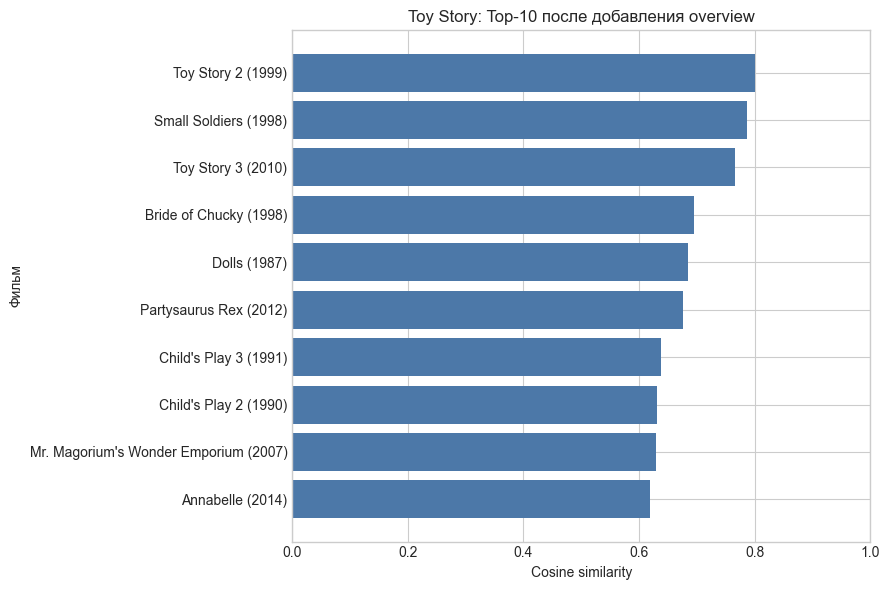

Новые рекомендации для 'The Matrix'


,rank,movie_label,vote_count,similarity
0,1,The Matrix Reloaded (2003),"3,500.000",0.786
1,2,The Matrix Revolutions (2003),"3,155.000",0.781
2,3,Ghost in the Shell (1995),854.000,0.671
3,4,The Thirteenth Floor (1999),381.000,0.635
4,5,Virtuosity (1995),163.000,0.620
5,6,Transcendence (2014),"2,339.000",0.577
6,7,The Animatrix (2003),433.000,0.571
7,8,The Zero Theorem (2014),383.000,0.571
8,9,The Lawnmower Man (1992),198.000,0.565
9,10,Terminator 3: Rise of the Machines (2003),"2,177.000",0.544


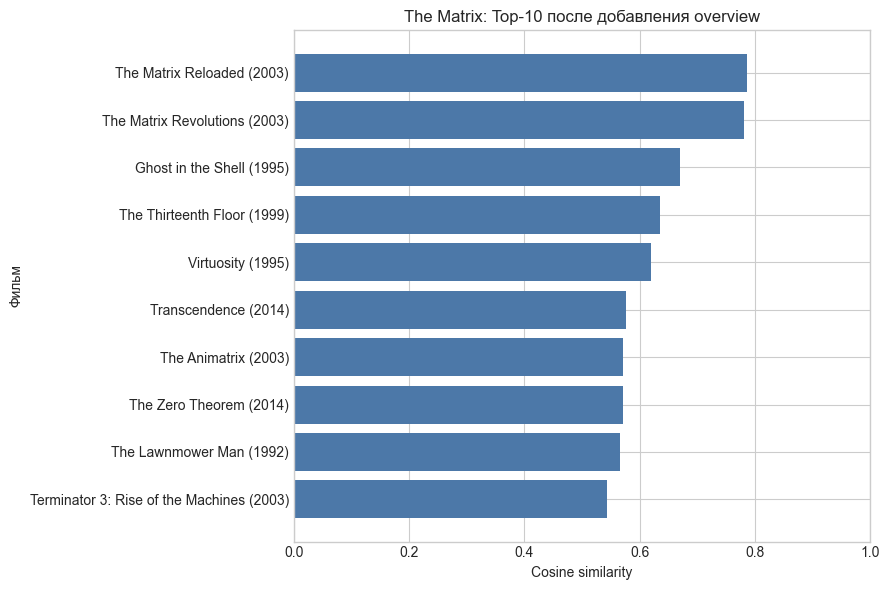

Новые рекомендации для 'Titanic'


,rank,movie_label,vote_count,similarity
0,1,The Legend of 1900 (1998),554.000,0.630
1,2,Captain Phillips (2013),"2,495.000",0.563
2,3,Triangle (2009),623.000,0.511
3,4,Ghost Ship (2002),540.000,0.488
4,5,Poseidon (2006),594.000,0.482
5,6,Master and Commander: The Far Side of the World (2003),808.000,0.470
6,7,The Poseidon Adventure (1972),274.000,0.452
7,8,Aquarius (2016),97.000,0.451
8,9,In the Heart of the Sea (2015),"1,300.000",0.448
9,10,The Notebook (2004),"3,163.000",0.442


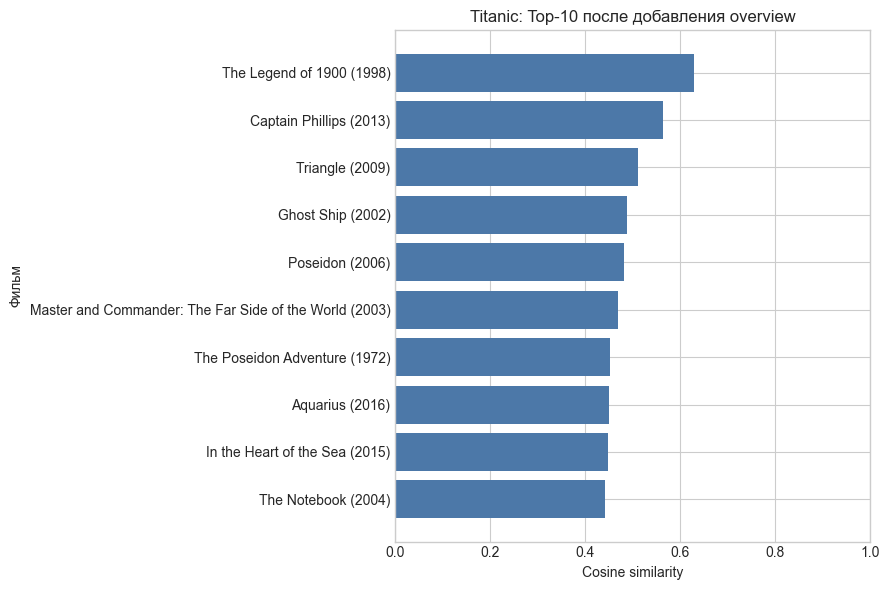

In [15]:
extended_recommendations: dict[str, pd.DataFrame] = {}

for title in SELECTED_TITLES:
    recs = recommend_top_k(title, working_catalog_extended, extended_similarity, top_k=10)
    extended_recommendations[title] = recs
    print(f"Новые рекомендации для '{title}'")
    display(recs[["rank", "movie_label", "vote_count", "similarity"]])
    plot_recommendations(recs, title, "Top-10 после добавления overview")

## Краткий комментарий к обновлённым рекомендациям

In [16]:
for title in SELECTED_TITLES:
    recs = extended_recommendations[title]
    top_titles = ", ".join(recs["title"].head(3).tolist())
    print(
        f"{title}: после добавления overview первые позиции занимают {top_titles}. "
        f"Средняя cosine similarity@10 = {mean_similarity_at_k(recs):.3f}."
    )

Toy Story: после добавления overview первые позиции занимают Toy Story 2, Small Soldiers, Toy Story 3. Средняя cosine similarity@10 = 0.693.
The Matrix: после добавления overview первые позиции занимают The Matrix Reloaded, The Matrix Revolutions, Ghost in the Shell. Средняя cosine similarity@10 = 0.632.
Titanic: после добавления overview первые позиции занимают The Legend of 1900, Captain Phillips, Triangle. Средняя cosine similarity@10 = 0.494.


# Задание 5. Сравнительный анализ и выводы

1. Рассчитать Overlap@10
2. Сравнить Mean Cosine Similarity@10
3. Сформулировать содержательные выводы по изменению рекомендаций

## Overlap@10 и Mean Cosine Similarity@10

,title,overlap@10,mean_similarity_base@10,mean_similarity_extended@10,delta_similarity
0,Toy Story,0.600,0.744,0.693,-0.051
1,The Matrix,0.600,0.641,0.632,-0.009
2,Titanic,0.000,0.485,0.494,0.008


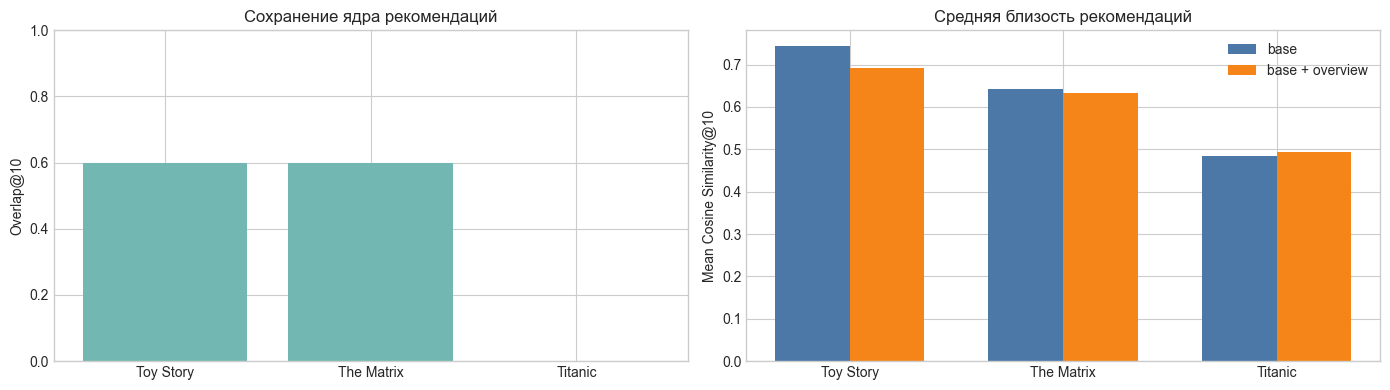

In [17]:
comparison_rows = []
for title in SELECTED_TITLES:
    base_recs = base_recommendations[title]
    ext_recs = extended_recommendations[title]
    comparison_rows.append(
        {
            "title": title,
            "overlap@10": overlap_at_k(base_recs, ext_recs),
            "mean_similarity_base@10": mean_similarity_at_k(base_recs),
            "mean_similarity_extended@10": mean_similarity_at_k(ext_recs),
            "delta_similarity": mean_similarity_at_k(ext_recs) - mean_similarity_at_k(base_recs),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(comparison_df["title"], comparison_df["overlap@10"], color="#72B7B2")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Overlap@10")
axes[0].set_title("Сохранение ядра рекомендаций")

x = np.arange(len(comparison_df))
width = 0.35
axes[1].bar(
    x - width / 2,
    comparison_df["mean_similarity_base@10"],
    width=width,
    label="base",
    color="#4C78A8",
)
axes[1].bar(
    x + width / 2,
    comparison_df["mean_similarity_extended@10"],
    width=width,
    label="base + overview",
    color="#F58518",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df["title"])
axes[1].set_ylabel("Mean Cosine Similarity@10")
axes[1].set_title("Средняя близость рекомендаций")
axes[1].legend()

plt.tight_layout()
plt.show()

## Содержательные выводы

In [18]:
for title in SELECTED_TITLES:
    print(summarize_shift(title, base_recommendations[title], extended_recommendations[title]))
    print()

Toy Story: часть ядра сохранилась, но обновление заметно; средняя близость немного снизилась, зато рекомендации стали разнообразнее. В новом списке появились: Child's Play 3, Partysaurus Rex, Dolls. Из базового списка ушли: Curse of Chucky, The Transformers: The Movie, Pinocchio.

The Matrix: часть ядра сохранилась, но обновление заметно; средняя близость изменилась слабо, но состав соседей всё равно уточнился. В новом списке появились: The Animatrix, The Zero Theorem, Transcendence. Из базового списка ушли: I, Robot, The Terminator, Vice.

Titanic: список рекомендаций перестроился довольно сильно; средняя близость изменилась слабо, но состав соседей всё равно уточнился. В новом списке появились: Triangle, The Notebook, Aquarius. Из базового списка ушли: Cruel Intentions, Romeo + Juliet, Jab Tak Hai Jaan.



# Итог

1. Данные из `movies_metadata.csv` и `keywords.csv` объединены, очищены от дублей и приведены к удобному табличному виду.
2. Построены две версии контентного описания: базовая (`genres + keywords`) и расширенная (`genres + keywords + overview`).
3. Для трёх фильмов получены top-10 рекомендации, а затем рассчитаны `Overlap@10` и `Mean Cosine Similarity@10`.
4. На практике добавление `overview` делает рекомендации менее "теговыми" и более сюжетными: ядро иногда сохраняется, но для фильмов с ярким сюжетом список может заметно перестраиваться.